In [2]:
#Project: Breast cancer data analysis(python)
#importing libraries
import numpy as np
import pandas as pd #tables(dataframe)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer


In [3]:
data=load_breast_cancer()
type(data) #what kind of object it is

sklearn.utils._bunch.Bunch

In [4]:
data.keys() 
#data=tumor measurements,target=diagnosis,target_names=malignant/benign ,feature_names=names of measurements ,DESCR=dataset desciption, 
#frame=panda table (each row =1 patient, each column = a tumor measurement)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [49]:

x=data.data
y=data.target

df=pd.DataFrame(x,columns=data.feature_names)   # create a table from my data #take the data in x and use data.feature_names as the column names)
df["target"]=y #adds disgnosis column)
df.head() #show the first 5 rows

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
print("x shape:",x.shape) #(rows,columns)
print("y shape:",y.shape)
print("df shape:", df.shape)


x shape: (569, 30)
y shape: (569,)
df shape: (569, 31)


In [16]:
df["target"].value_counts() #how many times each value appears (357 benign tumors and 212 malignant tumors)

target
1    357
0    212
Name: count, dtype: int64

In [17]:
df["diagnosis"]=df["target"].map({0:"malignant",1:"benign"}) #creates new column diagnosis and map puts text instead of numbers
df[["target","diagnosis"]].head()


,target,diagnosis
0,0,malignant
1,0,malignant
2,0,malignant
3,0,malignant
4,0,malignant


In [24]:
counts=df["diagnosis"].value_counts()
percent=counts/counts.sum() *100 #sum counts the numbers 357+212)
print(counts)
print("\n Percent %:")
print(percent.round(2)) #round(2) means only 2 dekadika (decimal places)

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

 Percent %:
diagnosis
benign       62.74
malignant    37.26
Name: count, dtype: float64


In [26]:
df.shape
data.target_names

array(['malignant', 'benign'], dtype='<U9')


## Day1-Dataset Overview
 dataset :**sklearn breast cancer dataset**
 
 Total samples:**569**
 
 Features:**30 tumor measurements**
 
 Classes:
  -**malignant**(cancerous)
  -**benign**(non cancerous)
  
 Class distribution:
  -malignant:**212 (37.26%)**
  -benign:**357(62.74%)**
  
 Observation:
 The dataset it slightly imbalanced but still suitable for classification models


In [30]:
df.describe()
df.isnull().sum().head(10)# checks missing values and should be zero here

mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

Text(0.5, 1.0, 'Feature correlation heatmap')

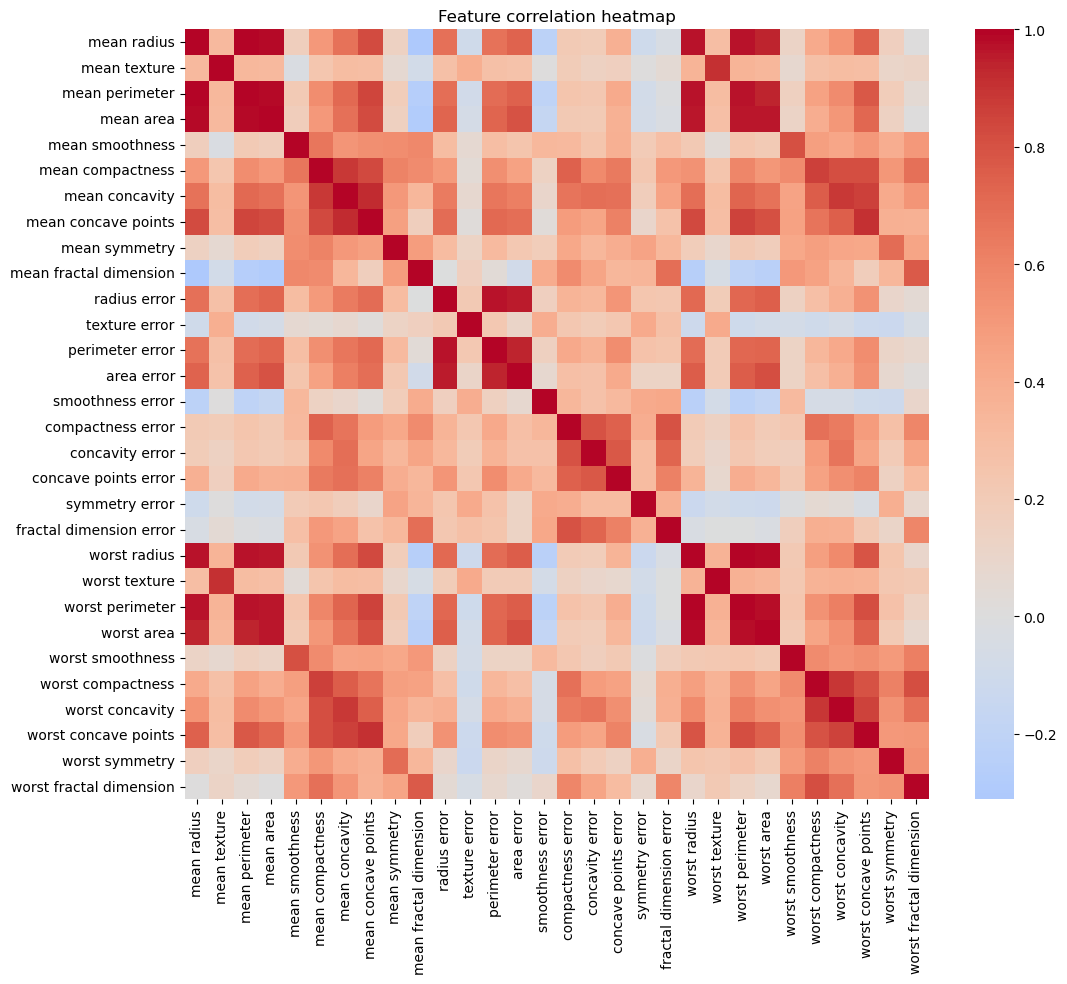

In [35]:
corr= df.drop(columns=["target"]).corr()    #remove diagnosis cause it contains words and not numbers and correlation is numerical
plt.figure(figsize=(12,10)) #size
sns.heatmap(corr, cmap="coolwarm", center=0) #plotting
plt.title("Feature correlation heatmap") #red=positive correlation ,#which features describe similar things 

In [ ]:
df=pd.Da

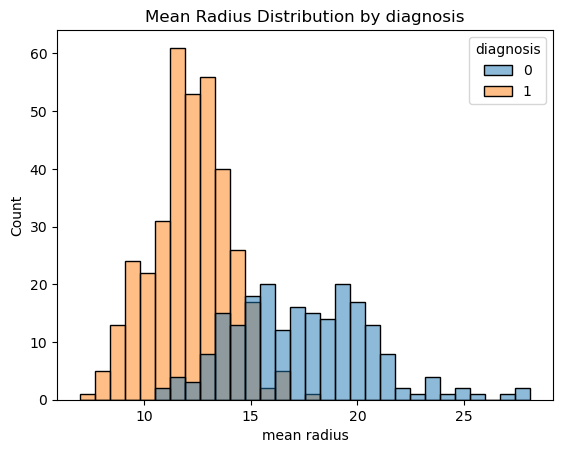

In [50]:
df=df.rename(columns={"target":"diagnosis"})
sns.histplot(data=df,x="mean radius",hue="diagnosis", bins=30)
plt.title("Mean Radius Distribution by diagnosis")
plt.show()

#benign mostly smaller tumours ,more comen
#some overlap in 13-15 so size is not a true indicator for diagmjl

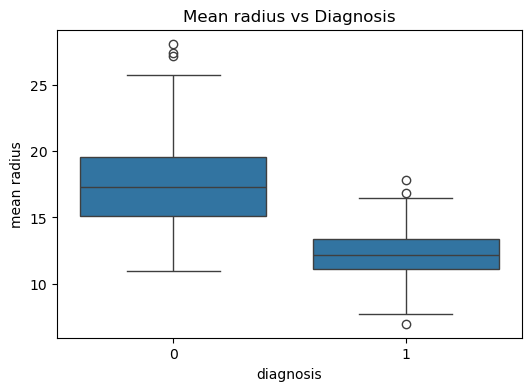

In [51]:

plt.figure(figsize=(6,4))
sns.boxplot( data=df, x="diagnosis", y="mean radius")
plt.title("Mean radius vs Diagnosis")

    
plt.show()
#large box=more variation higher median for cancer

## DAY 2- SUMMARY
-Summary statistics show variation in tumour measurements across samples.
-Correlation analysis show strong relation between size related paramaters such as radius, perimeter and are
-Visualizations show that malignant tumours tend to have larger mean radius compared to benign tumours and more variation but benign tumours have the numerical advantage.
-Observing the histogram it is clear there is a small overlap between the 2 so we can conclude that in that area, size is not a valid indicator for the diagnosis



In [55]:
from sklearn.model_selection import train_test_split  #machine learning, train data and then see how accurate it is on the remaining 114
X=df.drop(columns=["diagnosis"])
y=df["diagnosis"]
X_train, X_test , y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [57]:
#scaling
from sklearn.preprocessing import StandardScaler #prepares data so all features are on the same scale
scaler=StandardScaler() #scale object , get the calculations started
X_train_scaled=scaler.fit_transform(X_train)#standarization
X_test_scaled=scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression  #classifier that predicts cancer vs non-cancer
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train) #learn patterns that connect tumor measurements-x and diagnosis-y

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


ROC AUC: 0.9953703703703703


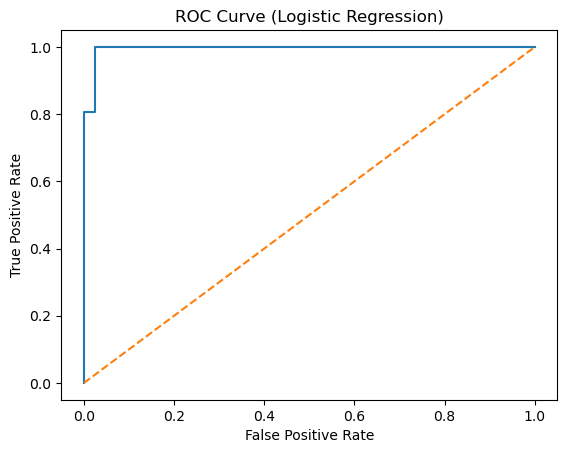

In [61]:
#ROC curve #can our model reallly distinguish between the 2 in different thresholds?
from sklearn.metrics import roc_curve, roc_auc_score #curve builds the curve points and sxore calculates the area under the curve
proba=lr.predict_proba(X_test_scaled)[:,1] #probsbillity of 1 benign (all rows, only column 1 which is benign) list[0.90,0.20,...]
auc=roc_auc_score(y_test, proba)#calculate how good the model is at seperating the classes 1 is perfect
print("ROC AUC:",auc)
fpr , tpr,_=roc_curve(y_test, proba)
plt.plot(fpr, tpr)
plt.plot ([0,1],[0,1], linestyle="--") #draws the diagonal dashed line =random guessing it should be above here
plt.xlabel("False Positive Rate")#out of the negative ones how many did it label as positive?
plt.ylabel("True Positive Rate")#out of bening tumors how many did the model correctly predict? higher is better
plt.title("ROC Curve (Logistic Regression)")
plt.show()
#roc- x is false positive and y is true positive
#it stays close to the left side so the model rarely mistakes malignant and benign rumors,it reaches the top border fast

### Day 3-Baseline model (Logistic Regression)
-Train test split:80/20 with stratification
-Applied scaling with StandardScaler
-Designed a roc curve which demonstrates excellent performance with an AUS score of 0.995 indicating near perfect ability to distinguish between malignant and benign tumors.The curve reaches the top fast and stays mostly on the left corner so it has excellent discriminative ability


In [64]:
from sklearn.svm import SVC #smart boundary between classes
from sklearn.ensemble import RandomForestClassifier #many decision tress working together
from sklearn.model_selection import cross_val_score #tests models on different data spilts,more reliable
models={"Logistic Regression":LogisticRegression(max_iter=5000),"SVM (RBF)": SVC(probability=True), "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42)}
#creates a list of models to compare

In [66]:
from sklearn.pipeline import Pipeline  #runs steps in order
results={}
for name , model in models.items():    #loop through each model
    if name in ["Logistic Regression", "SVM (RBF) "]:             #scalling, splitting data into 5 parts, train on 4,test on 1
        pipe=Pipeline([("scaler",StandardScaler()), ("model", model)])
        scores=cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    else: scores= cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results[name]=scores
    print(name, "mean=", scores.mean().round(4), "std=", scores.std().round(4))

#best model is Logistic Regressiob


Logistic Regression mean= 0.9807 std= 0.0065
SVM (RBF) mean= 0.9122 std= 0.0354
Random Forest mean= 0.9614 std= 0.0245


In [69]:
from sklearn.metrics import accuracy_score, classification_report #imports tools to evaluate performance
best_model=Pipeline([("scaler", StandardScaler()),("model",LogisticRegression(max_iter=5000))])
best_model.fit(X_train, y_train) #train the best possible model
pred_best=best_model.predict(X_test)
print("Test accuracy:",accuracy_score(y_test, pred_best))
print(classification_report(y_test,pred_best,target_names=data.target_names))


Test accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [70]:
feature_importance=pd.Series(best_model.named_steps["model"].coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)
feature_importance.head(10)
#which tumor measurement mattered most for the model


worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
worst perimeter        -0.763220
worst smoothness       -0.746625
dtype: float64

## Day 4-Model evaluation and Interpretation
-Compared Logistic Regression SVM, and Random Forest using 5-fold cross-validation
-Applied scaling with a Pipeline for fair modek comparison
-Logistic Regression achieved the best and most stable accuracy
-Trained final pipeline (StandardScaler + Logistic Regression) on training data
-Evaluated on test set-98% accuracy with strong precision and recall
-Ranked Logistic Regression coefficients to identify most important tumor features .Logistic Regression identifies texture, radius-related measures,concavity and tumor area as the most influential features for diagnosis
**Conclusion**Logistic Regression
performs excellently and key features strongly influence diagnosis predictions


## Final Project Summary-Breast Cancer Classification
**Goal**
Build a machine learing model to classify breas tumors as either **malignant** or **benign** using quantitative tumor measurements.
**Dataset**
-sklearn Breast Cancer dataset
-569 Breast Cancer dataset
-Features describe tumor size, shape, texture and different structural properties
---
## Exploratory Data Analysis
-Generated summary statistics to understand feature distributions
-Visualized feature behavior using:
  -Histograms
  -Boxplots
  -Correlation heatmap
-Observed strong correlations among size related features( radius, perimeter , area)
-Malignant tumors generally show larger variation and size measurements
-Some overlap exists so size alone is not a perfect indicator
---
## ⚙️ Data Preparation
- Split dataset into **training (80%)** and **test (20%)** sets  
- Used **stratified sampling** to preserve class balance  
- Applied **StandardScaler** to normalize feature ranges

---

## 🤖 Model Development
**Baseline model:** Logistic Regression

**Model comparison (5-fold Cross-Validation):**
- Logistic Regression → **Mean accuracy: 0.9807 ± 0.0065**
- Random Forest → Mean accuracy: 0.9614 ± 0.0245
- SVM (RBF) → Mean accuracy: 0.9122 ± 0.0354

**Best model:** Logistic Regression 
- Highest accuracy
- Most stable performance (lowest variance)

---

## 📈 Final Model Evaluation (Test Set)
- **Test Accuracy:** 98.25%
- Strong class performance:
| Class | Precision | Recall | F1-score |
|------------|-----------|--------|----------|
| Malignant | 0.98 | 0.98 | 0.98 |
| Benign | 0.99 | 0.99 | 0.99 |

- Balanced performance across both tumor types

---

## 📉 ROC Curve Analysis
- ROC AUC Score: **0.995**
- Curve rises steeply and stays near top-left corner
- Indicates near-perfect discrimination ability
- Model effectively separates malignant from benign cases

---

## 🧠 Feature Importance (Logistic Regression Coefficients)
Most influential tumor characteristics include:
- Worst texture
- Radius error
- Worst concave points
- Worst area
- Worst radius
- Worst symmetry
- Area error
- Worst concavity
- Worst perimeter
- Worst smoothness

These features strongly contribute to diagnosis predictions.

---

## ✅ Conclusion
Logistic Regression provides excellent, reliable performance for breast tumor classification.  
Tumor size and shape-related features are the strongest diagnostic indicators.Although individual size-related features show overlap between malignant and benign tumors, combining multiple size and shape characteristics significantly improves diagnostic accuracy. The model learns patterns across many measurements, making tumor morphology collectively a strong predictor of malignancy.The model demonstrates strong potential for clinical decision-support applications.





